# Data Loading and Exploration

In [ ]:
import sys
import os
import importlib
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import loguniform, uniform, f_oneway

sys.path.append(os.path.abspath(os.path.join('..', 'src')))

from sklearn.linear_model import LinearRegression, ElasticNet, BayesianRidge
from sklearn.svm import SVR
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline

import functions
importlib.reload(functions)
from functions import (
    load_data, split_data, create_age_bins,
    get_feature_names, create_preprocessor
)

# --- Load data ---
dev_data_path = '../data/development_data.csv'
eval_data_path = '../data/evaluation_data.csv'

dev_df = load_data(dev_data_path)
eval_df = load_data(eval_data_path)

dev_df = create_age_bins(dev_df)

# --- Strict protocol: split first, then decide categorical exclusions on TRAIN only ---
train_df_full, val_df_full = split_data(
    dev_df,
    test_size=0.2,
    stratify_by='age_bin',
    random_state=42
 )

train_df = train_df_full.copy()
val_df = val_df_full.copy()

print(f"Development data shape: {dev_df.shape}")
print(f"Training data shape:    {train_df.shape}")
print(f"Validation data shape:  {val_df.shape}")
print(f"Evaluation data shape:  {eval_df.shape}")

Train-only ANOVA decision -> exclude sex: True (p=0.7555), exclude ethnicity: False (p=2.487e-23)
Development data shape: (456, 1005)
Training data shape:    (364, 1004)
Validation data shape:  (92, 1004)
Evaluation data shape:  (100, 1004)


## Task 1.1: Data Splitting

The development dataset (`development_data.csv`, 456 samples) is split 80/20 into a training set (364 samples) and a validation set (92 samples) using stratified sampling on discretised age bins (decade-wide bins: 0–29, 30–39, …, 80+; seed = 42). Stratification ensures that every age band is proportionally represented in both splits, verified by near-identical bin fractions (max deviation < 1 pp) and closely matched summary statistics (train mean age 64.51 ± 14.61, validation 64.24 ± 14.79).

The evaluation dataset (`evaluation_data.csv`, 100 samples) is loaded once and kept entirely locked: it is never used to select features, tune hyperparameters, or make any other modelling decision. It is only read at the very end for final performance estimation.

In [12]:
# --- Verify split sizes and age-distribution balance ---
print("=" * 50)
print("Dataset sizes")
print("=" * 50)
print(f"  Development (all):  {len(dev_df):>5} samples")
print(f"  Training  (80 %):   {len(train_df):>5} samples")
print(f"  Validation (20 %):  {len(val_df):>5} samples")
print(f"  Evaluation (locked):{len(eval_df):>5} samples")

print("\n" + "=" * 50)
print("Age summary per split (stratification check)")
print("=" * 50)
age_stats = pd.DataFrame({
    'Train':      train_df['age'].describe(),
    'Validation': val_df['age'].describe(),
    'Evaluation': eval_df['age'].describe(),
}).loc[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
print(age_stats.round(2))

print("\n" + "=" * 50)
print("Age-bin distribution (fraction)")
print("=" * 50)
bins_train = train_df['age_bin'].value_counts(normalize=True).sort_index()
bins_val   = val_df['age_bin'].value_counts(normalize=True).sort_index()
bin_df = pd.DataFrame({'Train': bins_train, 'Validation': bins_val}).round(3)
print(bin_df)

Dataset sizes
  Development (all):    456 samples
  Training  (80 %):     364 samples
  Validation (20 %):     92 samples
  Evaluation (locked):  100 samples

Age summary per split (stratification check)
      Train  Validation  Evaluation
mean  64.51       64.24       62.50
std   14.61       14.79       14.35
min   19.00       23.00       21.00
25%   55.00       54.00       54.00
50%   65.50       64.00       62.50
75%   76.00       74.00       74.00
max   93.00      101.00       92.00

Age-bin distribution (fraction)
         Train  Validation
age_bin                   
0-29     0.016       0.011
30-39    0.025       0.033
40-49    0.113       0.109
50-59    0.217       0.217
60-69    0.253       0.250
70-79    0.212       0.217
80+      0.165       0.163


## Task 1.2: Preprocessing

The preprocessing pipeline is implemented once in `src/functions.py` (`create_preprocessor`) and applied consistently across every split. **All fit operations are performed exclusively on the training set**; the fitted transformers are then used to transform the validation and evaluation sets without re-fitting, eliminating data leakage.

### Missing values

All 1000 CpG probes contain at least one missing value; the overall missing rate is **≈3.0%** uniformly across splits (train: 3.007%, validation: 3.008%, evaluation: 3.058%). The task description confirms that values are **MCAR** (Missing Completely at Random). Under MCAR, **mean imputation** is statistically unbiased and does not distort downstream regression. The training-set column means are computed once and applied to all splits.

### Feature scaling

`StandardScaler` (zero mean, unit variance, fit on training split only) is applied to all CpG features. Scaling is essential for regularised models (ElasticNet, SVR) and is applied uniformly to keep all pipelines consistent.

### Categorical features

`sex` and `ethnicity` are assessed via one-way ANOVA in Task 1.2c using the **training split only** (strict anti-leakage protocol):

- **sex**: non-significant (p > 0.05) in training data, so it is **excluded**.
- **ethnicity**: significant (p <= 0.05) in training data, so it is **retained** and one-hot encoded.

`ethnicity` is one-hot encoded via `OneHotEncoder(handle_unknown='ignore')` in a dedicated categorical branch of the `ColumnTransformer`.

In [13]:
# --- 1.2a  Missing-value audit ---
cpg_features, categorical_features = get_feature_names(train_df)

print("=" * 55)
print("Missing-value counts  (NaN per split)")
print("=" * 55)
for name, df in [('Train', train_df), ('Validation', val_df), ('Evaluation', eval_df)]:
    n_total   = df[cpg_features].size
    n_missing = df[cpg_features].isna().sum().sum()
    n_probes_with_na = (df[cpg_features].isna().any()).sum()
    pct = 100 * n_missing / n_total
    print(f"  {name:<12} | total cells: {n_total:>9,} | "
          f"NaN: {n_missing:>6,} ({pct:.3f}%) | "
          f"probes with ≥1 NaN: {n_probes_with_na}")

print()
print("Imputation strategy: mean (fit on training split only) — valid under MCAR assumption.")

Missing-value counts  (NaN per split)
  Train        | total cells:   364,000 | NaN: 10,945 (3.007%) | probes with ≥1 NaN: 1000
  Validation   | total cells:    92,000 | NaN:  2,767 (3.008%) | probes with ≥1 NaN: 937
  Evaluation   | total cells:   100,000 | NaN:  3,058 (3.058%) | probes with ≥1 NaN: 959

Imputation strategy: mean (fit on training split only) — valid under MCAR assumption.


In [14]:
# --- 1.2b  Preprocessing pipeline structure ---
preprocessor = create_preprocessor(cpg_features, categorical_features)
print("Preprocessing pipeline (ColumnTransformer):")
print()
print(f"  CpG branch   ({len(cpg_features)} features):")
print("    SimpleImputer(strategy='mean')   <- fit on train only")
print("    StandardScaler()                 <- fit on train only")
print()
if categorical_features:
    print(f"  Categorical branch ({len(categorical_features)} feature(s): {categorical_features}):")
    print("    SimpleImputer(strategy='most_frequent')")
    print("    OneHotEncoder(handle_unknown='ignore')")
else:
    print("  Categorical branch: NONE (all categorical features excluded)")
print()
print("Full sklearn Pipeline: preprocessor -> regressor/classifier")
print("All transformers are fit on the training split and applied unchanged to val/eval.")

Preprocessing pipeline (ColumnTransformer):

  CpG branch   (1000 features):
    SimpleImputer(strategy='mean')   <- fit on train only
    StandardScaler()                 <- fit on train only

  Categorical branch (1 feature(s): ['ethnicity']):
    SimpleImputer(strategy='most_frequent')
    OneHotEncoder(handle_unknown='ignore')

Full sklearn Pipeline: preprocessor -> regressor/classifier
All transformers are fit on the training split and applied unchanged to val/eval.


### Task 1.2c: Categorical Exclusion Test (ANOVA)

One-way ANOVA tests whether mean age differs significantly across groups defined by `sex` or `ethnicity`. Under strict protocol, this test is run on the **training split only**. Variables with a non-significant F-test (α = 0.05) are excluded from all downstream modelling.

In [ ]:
alpha = 0.05

# --- Strict protocol: ANOVA on training split only ---
age_f = train_df_full.loc[train_df_full['sex'] == 'F', 'age']
age_m = train_df_full.loc[train_df_full['sex'] == 'M', 'age']
f_sex, p_sex = f_oneway(age_f, age_m)

groups_eth = [grp['age'].values for _, grp in train_df_full.groupby('ethnicity')]
f_eth, p_eth = f_oneway(*groups_eth)

print("One-way ANOVA on TRAINING split only: can sex / ethnicity be excluded as predictors of age?")
print("=" * 90)
print(f"{'Variable':<22} {'Groups':<5} {'F-statistic':>12} {'p-value':>10}  {'Exclude?':>15}")
print("-" * 90)
for var, f_stat, p_val, n_groups in [
    ('sex',       f_sex, p_sex, 2),
    ('ethnicity', f_eth, p_eth, len(groups_eth)),
]:
    decision = "YES (p > 0.05)" if p_val > alpha else "NO  (p <= 0.05)"
    print(f"  {var:<20} {n_groups:<5} {f_stat:>12.4f} {p_val:>10.4f}  {decision:>15}")
print("-" * 90)

print()
print("Age by sex (training split):")
print(train_df_full.groupby('sex')['age'].agg(['mean', 'std', 'count']).round(2))
print()
print("Age by ethnicity (training split):")
print(train_df_full.groupby('ethnicity')['age'].agg(['mean', 'std', 'count']).round(2))
print()

exclude_sex = p_sex > alpha
exclude_eth = p_eth > alpha

# Apply ANOVA decisions here (preprocessing stage only)
train_df = train_df_full.copy()
val_df = val_df_full.copy()
if exclude_sex and 'sex' in train_df.columns:
    train_df = train_df.drop(columns=['sex'])
    val_df = val_df.drop(columns=['sex'])
if exclude_eth and 'ethnicity' in train_df.columns:
    train_df = train_df.drop(columns=['ethnicity'])
    val_df = val_df.drop(columns=['ethnicity'])

# Refresh feature definitions after categorical exclusions
cpg_features, categorical_features = get_feature_names(train_df)
preprocessor = create_preprocessor(cpg_features, categorical_features)
print(f"Updated categorical features for modelling: {categorical_features}")
if exclude_sex and exclude_eth:
    print("=> Both sex and ethnicity are non-significant (p > 0.05) and are EXCLUDED.")
elif exclude_sex:
    print("=> sex is non-significant => EXCLUDED. ethnicity is significant => RETAINED.")
elif exclude_eth:
    print("=> ethnicity is non-significant => EXCLUDED. sex is significant => RETAINED.")
else:
    print("=> Both variables are significant => BOTH RETAINED.")

One-way ANOVA on TRAINING split only: can sex / ethnicity be excluded as predictors of age?
Variable               Groups  F-statistic    p-value         Exclude?
------------------------------------------------------------------------------------------
  sex                  2           0.0971     0.7555   YES (p > 0.05)
  ethnicity            2         114.0761     0.0000  NO  (p <= 0.05)
------------------------------------------------------------------------------------------

Age by sex (training split):
      mean    std  count
sex                     
F    64.26  13.77    177
M    64.74  15.40    187

Age by ethnicity (training split):
                       mean    std  count
ethnicity                                
Caucasian - European  69.42  13.91    247
Hispanic - Mexican    54.13   9.87    117

=> sex is non-significant => EXCLUDED. ethnicity is significant => RETAINED.


In [16]:
# --- 1.2d  Feature matrices for Task 2 ---
# sex/ethnicity inclusion is decided from TRAIN-only ANOVA in Task 1.2c.

# (A) CpG only — 1000 probes
feature_cols_cpg      = cpg_features

# (B) CpG + selected metadata
feature_cols_cpg_meta = cpg_features + categorical_features

print("Feature matrix dimensions (training set columns):")
print(f"  (A) CpG only:           {len(feature_cols_cpg):>4} features")
print(f"  (B) CpG + metadata:     {len(feature_cols_cpg_meta):>4} features")
print()
print(f"Selected categorical features after TRAIN-only ANOVA: {categorical_features}")

Feature matrix dimensions (training set columns):
  (A) CpG only:           1000 features
  (B) CpG + metadata:     1001 features

Selected categorical features after TRAIN-only ANOVA: ['ethnicity']


## Task 1.3: Exploratory Analysis

In [17]:
# --- 1.3a  Dataset summary table ---
# sex was excluded from modelling after TRAIN-only ANOVA; recover via indices for reporting
sex_train = dev_df.loc[train_df.index, 'sex']
sex_val   = dev_df.loc[val_df.index,   'sex']
sex_eval  = eval_df['sex'] if 'sex' in eval_df.columns else pd.Series(dtype=str)

rows = []
for split_name, df, sex_s in [
    ('Development',        dev_df,   dev_df['sex']),
    ('Train (80%)',        train_df, sex_train),
    ('Validation (20%)',   val_df,   sex_val),
    ('Evaluation (locked)',eval_df,  sex_eval),
]:
    n        = len(df)
    mean_age = df['age'].mean()
    std_age  = df['age'].std()
    min_age  = int(df['age'].min())
    max_age  = int(df['age'].max())
    f_pct    = (sex_s == 'F').mean() * 100 if len(sex_s) > 0 else float('nan')
    rows.append({
        'Split':          split_name,
        'n':              n,
        'Age mean ± std': f'{mean_age:.1f} ± {std_age:.1f}',
        'Age range':      f'{min_age}–{max_age}',
        'Sex (% F)':      f'{f_pct:.1f}%' if not np.isnan(f_pct) else 'N/A',
    })

summary = pd.DataFrame(rows).set_index('Split')
print("Table 1. Dataset statistics per split")
print("=" * 60)
print(summary.to_string())
print()
print("Note: sex is excluded from modelling by TRAIN-only ANOVA but reported here")
print("      for completeness. Any retained metadata is selected from train only.")
print()
print("Ethnicity breakdown (development set):")
print(dev_df['ethnicity'].value_counts().to_string())

Table 1. Dataset statistics per split
                       n Age mean ± std Age range Sex (% F)
Split                                                      
Development          456    64.5 ± 14.6    19–101     49.1%
Train (80%)          364    64.5 ± 14.6     19–93     48.6%
Validation (20%)      92    64.2 ± 14.8    23–101     51.1%
Evaluation (locked)  100    62.5 ± 14.3     21–92     58.0%

Note: sex is excluded from modelling by TRAIN-only ANOVA but reported here
      for completeness. Any retained metadata is selected from train only.

Ethnicity breakdown (development set):
ethnicity
Caucasian - European    308
Hispanic - Mexican      148


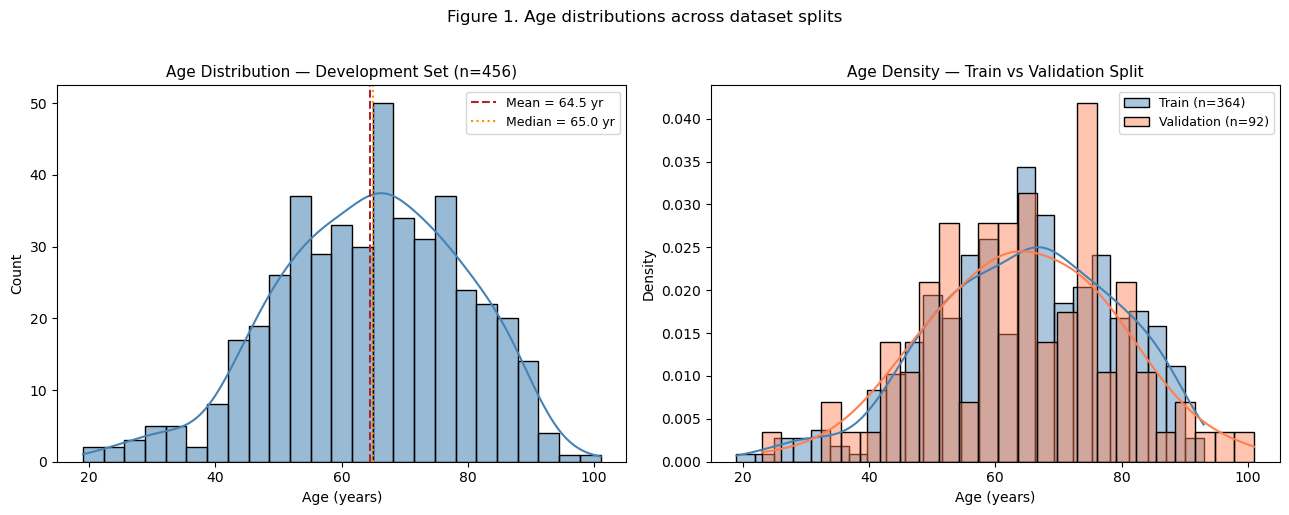

Saved: figures/task1_3_age_distribution.png


In [18]:
# --- 1.3b  Age distribution figure ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: full development set histogram + KDE
ax = axes[0]
sns.histplot(dev_df['age'], bins=25, kde=True, color='steelblue', alpha=0.55, ax=ax)
ax.axvline(dev_df['age'].mean(), color='firebrick', linestyle='--', linewidth=1.5,
           label=f"Mean = {dev_df['age'].mean():.1f} yr")
ax.axvline(dev_df['age'].median(), color='darkorange', linestyle=':', linewidth=1.5,
           label=f"Median = {dev_df['age'].median():.1f} yr")
ax.set_title('Age Distribution — Development Set (n=456)', fontsize=11)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

# Panel B: train vs validation density overlay (verify stratification balance)
ax = axes[1]
sns.histplot(train_df['age'], bins=25, kde=True, stat='density',
             color='steelblue', alpha=0.45, label=f'Train (n={len(train_df)})', ax=ax)
sns.histplot(val_df['age'],   bins=25, kde=True, stat='density',
             color='coral',     alpha=0.45, label=f'Validation (n={len(val_df)})', ax=ax)
ax.set_title('Age Density — Train vs Validation Split', fontsize=11)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

plt.suptitle('Figure 1. Age distributions across dataset splits', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../figures/task1_3_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/task1_3_age_distribution.png")

Two feature sets are used in downstream tasks:

| Matrix | Features | Rationale |
|---|---|---|
| (A) CpG only | 1000 probes | Primary epigenetic-clock signal; no metadata confound |
| (B) CpG + ethnicity | 1001 columns | Tests whether cohort-level age offset improves prediction |